In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
from utils.corr import corr_by_regime, pairwise_metric, bootstrap_spearman
from utils.plots import scatterplot_finetuned # scatterplot, plot_unified_agreement_heatmap, get_family, parse_size 
from analyzer import * 
from utils.corr import human_vs_consensus 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
mm = MMStarResults()
answers_pivot = mm.combine_mh() 
md = mm.model 
vlms=md[md['model_type'] != 'llm'].model.unique() 
llms=md[md['model_type'] == 'llm'].model.unique() 
all_humans = mm.human.participant_id.unique()  

/home/work/yuna/HPA/evaluation/analysis/analyzer.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


14 6
[]


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:175: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df['category'].map(mmstar_cat_map)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['question_id'] = df['question_id'].astype('Int64')


In [ ]:
hm_acc = mm.human.groupby([ 'category', 'l2_category', 'question_id'])['correct'].mean().reset_index()
alignment_results = []
n_boot = 1000

for vlm in md.model.unique() : 
    hm = pd.merge(hm_acc, md[md['model'] == vlm], 
                    on=['category', 'l2_category', 'question_id'], 
                    how='inner',
                    suffixes=("_human", '_model'))  
    theta_hat = pairwise_metric(hm['correct_model'].values, hm['correct_human'].values)  
    
    if n_boot: 
        boot =  bootstrap_spearman(hm['correct_model'].values, hm['correct_human'].values, n_boot, 42) 
        ci = np.percentile(boot, [2.5, 97.5]) # 95% percentile CI

    alignment_results.append({
        'model': vlm, 
        'theta_hat': theta_hat, 
        "ci": ci
        # 'data': hm 
    }) 
df = pd.DataFrame(alignment_results)
df.to_csv('./correlations/mmstar.csv')

models = df.model.values # list(alignment_results.keys())
rhos = df.theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])
ci_lows = np.array([c[0] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
ci_highs = np.array([c[1] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

human_correct =mm.human.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct = (human_correct > 0).astype(int)
human_rhos = human_vs_consensus(human_correct) 
low, high = np.percentile(human_rhos, [2.5, 97.5])
mu = human_rhos.mean()
sd = human_rhos.std()
human_correct.shape , mu,sd 

((20, 247), 0.290796260316054, 0.09906076795651508)

In [ ]:
df = pd.read_csv('./correlations/mmstar.csv')
df 

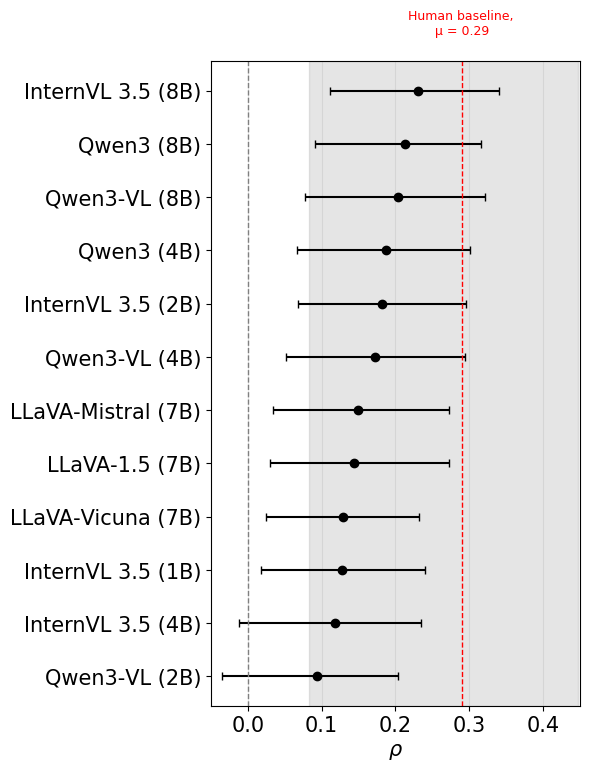

In [68]:
order = np.argsort(rhos)
models = [models[i] for i in order]
rhos = rhos[order]
ci_lows = ci_lows[order]
ci_highs = ci_highs[order]
y = np.arange(len(models))

plt.figure(figsize=(6, 3 + 0.4 * len(models)))
plt.errorbar(
    rhos,
    y,
    xerr=[rhos - ci_lows, ci_highs - rhos],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1.5,
    capsize=3,
)

plt.yticks(y, models)
plt.xlabel(r"$\rho$") # Spearman correlation to human consensus 
# plt.title("Model–Human Alignment")
plt.axvspan(
    low,
    high,
    color="gray",
    alpha=0.2,
    label="Human baseline (95%)"
)

plt.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=1
)
plt.text(
    mu,
    len(models),
    f"Human baseline, \nμ = {mu:.2f}",
    ha="center",
    va="bottom",
    fontsize=9,
    color="red"
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.xlim(-0.05, 0.45)   # or tighter: (0.0, 0.4)
plt.tight_layout()
plt.show()

## VQA 

In [72]:
vv = VQAResults()   
human_vqa = vv.human.drop_duplicates(subset=['question_id', 'participant_id']) 
model_vqa = vv.model 

# get_agreements(human_vqa, model_vqa, metrics="correct", n_boot=200) 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
before 38.98698056001426
after  39.8876404494382
14 6
[]
before 56.376171604938264
after  56.553126337448575
[]
before 56.50236445408408
after  56.66504286986308


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:397: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)


processed_ans                                 1
correct                                   100.0
gt_answers       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Name: 6424, dtype: object

In [ ]:
# hm_sim = mm.human.groupby(['question_id'])[''].mean().values
hm_acc = human_vqa.groupby(['answer_type', 'question_type', 'question_id'])[['correct', 'answer_similarity']].mean().reset_index()
alignment_results = []
n_boot = 1000 

for metric in ['answer_similarity', 'correct']: 
    for vlm in model_vqa.model.unique() : 
        hm = pd.merge(hm_acc, model_vqa[model_vqa['model'] == vlm], 
                        on=['answer_type', 'question_type', 'question_id'], 
                        how='inner',
                        suffixes=("_human", '_model'))  
        theta_hat = pairwise_metric(hm[f'{metric}_model'].values, hm[f'{metric}_human'].values)  
        
        if n_boot: 
            boot =  bootstrap_spearman(hm[f'{metric}_model'].values, hm[f'{metric}_human'].values, n_boot, 42) 
            ci = np.percentile(boot, [2.5, 97.5]) # 95% percentile CI 

        alignment_results.append({ 
            'model': vlm, 
            'theta_hat': theta_hat, 
            "ci": ci, 
            'metric': metric 
            # 'data': hm 
        }) 
df = pd.DataFrame(alignment_results)
models = df.model.values # list(alignment_results.keys())
df.to_json('./correlations/vqa.json')  

In [ ]:
df = pd.read_json('./correlations/vqa.json') 

In [ ]:
human_correct = human_vqa.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct = (human_correct > 0).astype(int)
human_rhos = human_vs_consensus(human_correct) 
low, high = np.percentile(human_rhos, [2.5, 97.5]) 
mu, sd = human_rhos.mean(), human_rhos.std() 

rhos_acc = df[df['metric'] == 'correct'].theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])
ci_lows_acc = np.array([c[0] for c in df[df['metric'] == 'correct'].ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
ci_highs_acc = np.array([c[1] for c in df[df['metric'] == 'correct'].ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

rhos_sim = df[df['metric'] == 'answer_similarity'].theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])
ci_lows_sim = np.array([c[0] for c in df[df['metric'] == 'answer_similarity'].ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
ci_highs_sim = np.array([c[1] for c in df[df['metric'] == 'answer_similarity'].ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

In [84]:
df['ci'] = df["ci"].tolist() 

In [87]:
rhos_acc, ci_lows_acc

(array([0.64332974, 0.62797595, 0.66918606, 0.66615304, 0.55693792,
        0.64511918, 0.67660228, 0.62503143, 0.49081622, 0.48903708]),
 array(['[', '[', '[', '[', '[', '[', '[', '[', '[', '['], dtype='<U1'))

In [80]:
rhos_acc - ci_lows_acc, ci_highs_acc - rhos_acc

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('float64'), dtype('<U1')) -> None

In [79]:
order = np.argsort(rhos_acc)
models = [models[i] for i in order]
rhos_acc = rhos_acc[order]
ci_lows_acc = ci_lows_acc[order]
ci_highs_acc = ci_highs_acc[order]

rhos_sim = rhos_sim[order] 
ci_lows_sim = ci_lows_sim[order] 
ci_highs_sim = ci_highs_sim[order] 

y = np.arange(len(models))

plt.figure(figsize=(6, 3 + 0.4 * len(models)))
plt.errorbar(
    rhos_acc,
    y,
    xerr=[rhos_acc - ci_lows_acc, ci_highs_acc - rhos_acc],
    fmt="o",
    color="black",
    capsize=3,
    label="Correctness"
)
offset = 0.015  # small horizontal separation
plt.scatter(
    rhos_sim + offset,
    y,
    marker="D",
    s=28,
    facecolors="none",
    edgecolors="black",
    linewidths=1,
    label="Answer similarity"
)
plt.yticks(y, models)
plt.xlabel(r"$\rho$") # Spearman correlation to human consensus 
# plt.title("Model–Human Alignment")
plt.axvspan(
    low,
    high,
    color="gray",
    alpha=0.2,
    label="Human baseline (95%)"
)

plt.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=1
)
plt.text(
    mu,
    len(models),
    f"Human baseline, \nμ = {mu:.2f}",
    ha="center",
    va="bottom",
    fontsize=9,
    color="red"
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.xlim(0.3, 0.9)   # or tighter: (0.0, 0.4)
plt.tight_layout()
plt.show()

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('float64'), dtype('<U1')) -> None

<Figure size 600x700 with 0 Axes>

In [ ]:

pcorr = self.get_corr('accuracy')  # pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr = pd.merge(pcorr, df, on=['model']) 
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]
pcorr['family'] = pcorr['model'].map(get_family)
pcorr['model_size'] = pcorr['model'].map(parse_size)  

scatterplot(pcorr, x_col='acc_corr', y_col='MG_Acc', title='accuracy')  
scatterplot(sim_corr, x_col='sim_corr', y_col='MG_S', title='simliarity')  

self.pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 

## MG Scatterplots 

In [ ]:

if isinstance(mg_df.columns, pd.MultiIndex):
    mg_df.columns = ['_'.join(str(c) for c in col if c != '') for col in mg_df.columns.values]

In [ ]:

pcorr = pd.merge(acc_corr, sim_corr, on =['model']) 
pcorr= pd.merge(pcorr.reset_index(), mg_df.reset_index(), on=['model'])  
pcorr = pcorr[~pcorr['model'].str.contains('MMStar')]
pcorr = pcorr[['model', 'acc_corr', 'sim_corr', 'MG_Acc', 'MG_S']]

pcorr = pcorr[~pcorr['model'].str.contains('|'.join(exclude_models))]
corr_by_regime(pcorr).to_latex('./tables/appendix/finetuned-pearson-r.tex', float_format="%.1f")    

for fam in pcorr.family.unique(): 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='acc_corr', y_col='MG_Acc', title=f'{fam} accuracy') # 
    scatterplot_finetuned(pcorr[(pcorr['family'] == fam) ] , x_col='sim_corr', y_col='MG_S', title=f'{fam} similairty') # 